In [34]:
# Numericala and plotting packages

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Units and constants
import astropy.units as u
from astropy.constants import G, c, M_sun, sigma_sb, h, k_B

#Numberical integration and interpolation
from scipy.integrate import quad, dblquad

# Plot formatting
plt.rcParams["font.family"] = "Times New Roman" #font

In [35]:
# Neutron Star and AccretionDisk Parameters 

M = 1.4 * M_sun
Mdot = 1e17 * u.g / u.s

R_in = 12e5 * u.cm
R_out = 1000e5 * u.cm

inclination = np.radians(45)
D = 5 * u.kpc

## Disk Temperature Profile

The effective temperature of a geometrically thin, optically thick accretion disk is calculated as a function of radius.

In [36]:
def disk_temp(R, M, Mdot, R_in):

    """
    Calculates the temperature of the disk at a given radius R, 
    given the mass of the neutron star M, the mass accretion rate 
    Mdot, and the inner edge of the disk R_in.

    Parameters:
    -----------
    R : Radius at which to calculate the temperature 
    M : Mass of the neutron star
    Mdot : Mass accretion rate
    R_in : Inner edge of the disk
    """

    term = (3 * G * M * Mdot) / (8 * np.pi * R**3 * sigma_sb)
    
    boundary = 1 - np.sqrt(R_in / R)

    return (term * boundary)**0.25

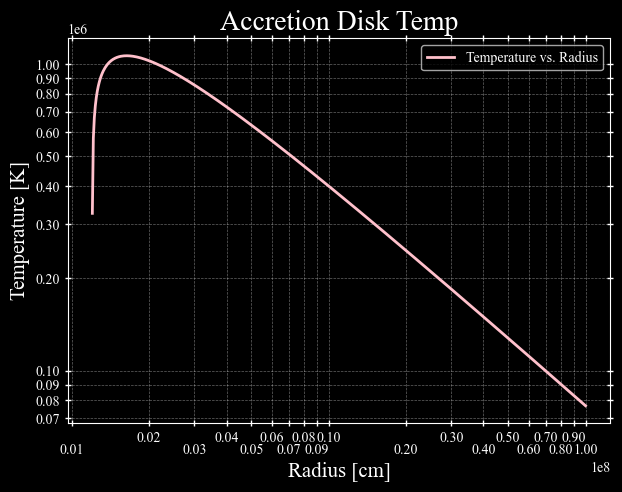

In [37]:
# Plotting the temperature based on R

# random radii
R_values = np.logspace(
    np.log10((R_in * 1.001).to(u.cm).value),
    np.log10((R_out).to(u.cm).value),
    500
) * u.cm

T_values = disk_temp(R_values, M, Mdot, R_in)

#plotting time

plt.figure(figsize=(7, 5))
plt.loglog(
    R_values, 
    T_values, 
    label = "Temperature vs. Radius", 
    linewidth = 2, 
    color = "pink"
    ) #legend


plt.xlabel("Radius [cm]", fontsize = 15)
plt.ylabel("Temperature [K]", fontsize = 15)
plt.title("Accretion Disk Temp", fontsize = 20)
plt.legend()
plt.minorticks_on()

#tick stuff
plt.grid(True, which = "both", ls = "--", lw = 0.5, alpha = 0.4)
plt.tick_params(axis = "both", which = "both", top = True, right = True, direction = "inout" , length = 3, width = 1, size = 4)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.LogLocator(base = 10, subs = np.arange(1.0, 10.0) * 0.1, numticks = 3))
ax.yaxis.set_major_locator(ticker.LogLocator(base = 10, subs = np.arange(1.0, 10.0) * 0.1, numticks = 3))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.ticklabel_format(axis = "both", style = "sci")
#end of tick stuff

plt.gcf().canvas.draw()
for i, j in enumerate(ax.xaxis.get_ticklabels()):
    if i % 2 != 0:
        j.set_y(j.get_position()[1] - 0.03)

# makes the ticks alternate

plt.show()



## Blackbody Emission

The Planck function is used to calculate the spectral radiance emitted by each annulus of the disk.

In [38]:
# Planck Function

def planck_nu(nu, T):
    """
    Calculates the Planck spectral radiance at a given frequency nu and temperature T.

    Parameters:
    -----------
    nu : Frequency 
    T : Temperature 
    """
    
    exponent = (h * nu / (k_B * T)).decompose().value #makes exponent dimensionless

    return (2 * h * nu**3 / c**2) / np.expm1(exponent)

# nu = frequency in Hertz, T = temp in K

In [39]:
def disk_integrand(R, nu, M, Mdot, R_in):
    """
    Calculates the radial integrand used to determine the disk flux at a given 
    radius R, frequency nu, mass of the neutron star M, mass accretion rate Mdot, 
    and inner edge of the disk R_in.

    Parameters:
    -----------
    R : Disk radius
    nu : Frequency
    M : Mass of the neutron star
    Mdot : Mass accretion rate
    R_in : Inner edge of the disk

    Returns:
    The radial integrand for the disk flux calculation.
    """

    T = disk_temp(R, M, Mdot, R_in)

    return 2 * np.pi * R * planck_nu(nu, T)

#Disk Flux Function

def disk_flux_nu(nu, M, Mdot, R_in, R_out, inclination, D):
    """
    Calculate the observed spectral flux density from the accretion disk.

    Parameters:
    ----------
    nu : observing frequency
    M : neutron star mass
    Mdot : mass accretion rate
    R_in : inner edge of the accretion disk
    R_out : outer edge of the accretion disk
    inclination : disk inclination angle in radians
    D : distance to the source
    """

    def integrand_for_quad(R_value):
        value = R_value * u.cm
        value = disk_integrand(value, nu, M, Mdot, R_in)

        return value.value # Return the value without units for integration
    
    integral, error = quad(
        integrand_for_quad,
        R_in.to(u.cm).value,
        R_out.to(u.cm).value,
    )

    sample_unit = disk_integrand(
    R_in * 1.001,
    nu,
    M,
    Mdot,
    R_in    
).unit

    integral = integral * sample_unit * u.cm # Reapply the unit after integration

    F_nu = (np.cos(inclination) / D**2) * integral
    return F_nu



In [40]:
def disk_bol_L(M, Mdot, R_in, R_out):
    """
    Calculate the total bolometric luminosity of the accretion disk
    by integrating disk emission over frequency and radius.

    Parameters:
    -----------
    M : Mass of the neutron star
    Mdot : Mass accretion rate
    R_in : Inner edge of the disk
    R_out : Outer edge of the disk

    Returns:
    L_bol : Total bolometric luminosity of the accretion disk
    """

    def integrand_for_dblquad(R_value, nu_value):
        #reattatching the physical units
        R = R_value * u.cm
        nu = nu_value * u.Hz

        value = disk_integrand(R, nu, M, Mdot, R_in)

        return value.to_value(
            u.erg / (u.s * u.Hz * u.cm)
        )

    integral, error = dblquad(
        integrand_for_dblquad, #tbh I am using chat to debug here bc I was having issues and I'm not totally sure what it's telling me to do
        1e10, 1e20, # frequency range in Hz
        lambda nu: R_in.to_value(u.cm), # lower limit of R
        lambda nu: R_out.to_value(u.cm)  # upper limit of R
    )

    #unit of og integrand
    sample_unit = disk_integrand(
        R_in * 1.001,
        1e17 * u.Hz,
        M,
        Mdot,
        R_in    
    ).unit

    integral = integral * sample_unit * u.cm * u.Hz # Reapply the unit after integration
    L_bol = integral * 4 * np.pi**2  # multiply by 4pi^2 for total luminosity
    return L_bol  # returning the total bolometric luminosity


In [41]:
#testing the flux fn
nu = 1e17 * u.Hz        

inclination = np.radians(45)

F_nu = disk_flux_nu( 
    nu,
    M,
    Mdot,
    R_in,
    R_out,
    inclination,
    D
    )

F_bol = disk_bol_L( 
    M,
    Mdot,
    R_in,
    R_out,
    )

L_acc = (0.1 * Mdot * c**2).to(u.erg / u.s) # converting to luminosity units

print("Accretion luminosity:", L_acc)
print("Flux at nu:", F_nu)
print("Bolometric luminosity:", F_bol)

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/1512803435.py:15: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)


Accretion luminosity: 8.987551787368176e+36 erg / s
Flux at nu: 83533395477411.53 Hz3 s3 cm2 J / (kpc2 m2)
Bolometric luminosity: 4.701843259600884e+37 Hz4 s3 cm2 J / m2


/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/1512803435.py:15: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)


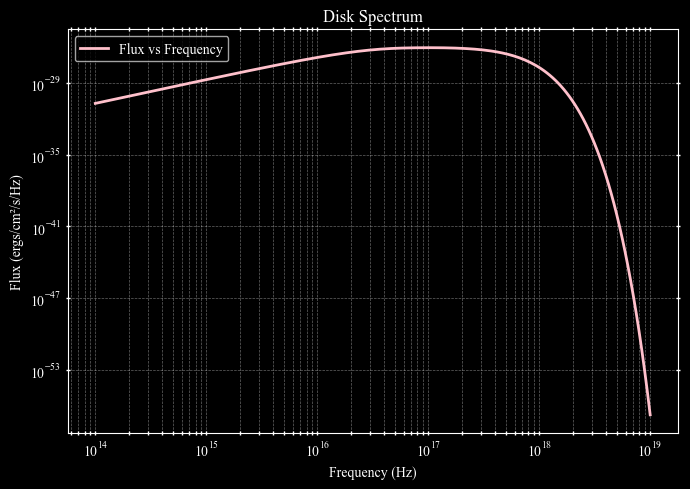

In [42]:
# Creating a spectrum

# Generating frequencies
frequencies = np.logspace(14, 19, 200)  # in Hz 

fluxes = []

for nu in frequencies:
    F = disk_flux_nu(
        nu * u.Hz,
        M,
        Mdot,
        R_in,
        R_out,
        inclination,
        D
    )
    fluxes.append(F.to_value(u.erg / (u.cm**2 * u.s * u.Hz)))  
    # Convert to desired units

fluxes = np.array(fluxes)

#Plotting 

plt.figure(figsize=(7, 5))
plt.loglog(
    frequencies, 
    fluxes, 
    label = "Flux vs Frequency", 
    linewidth = 2, 
    color = "pink"
    ) #legend(ary)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (ergs/cm²/s/Hz)")
plt.title("Disk Spectrum")
plt.legend()

plt.minorticks_on()


# grid
plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

# tick styling
plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="inout",
    length=3,
    width=1
)

ax = plt.gca()


# log tick locations
ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

# scientific notation labels
ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

# makes graph fit nicely
plt.tight_layout()

plt.show()

## Dependence on Neutron Star Mass

The disk spectra are compared for several neutron star masses while keeping the remaining disk parameters fixed.

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/1512803435.py:15: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)
/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/4073746174.py:46: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = quad(


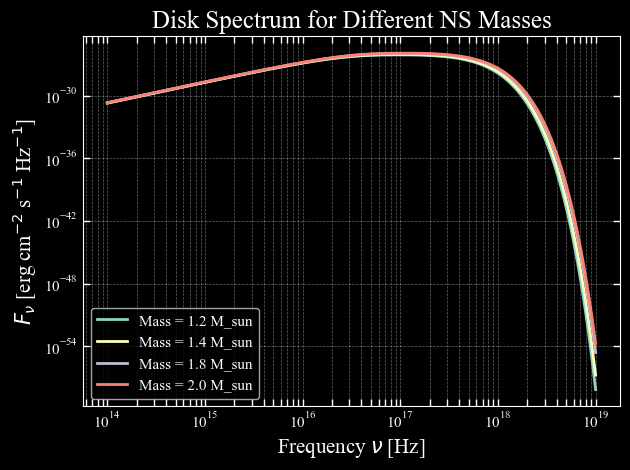

In [43]:
# Varying NS mass

# Example masses in solar masses
masses = [1.2, 1.4, 1.8, 2.0]

for mass in masses:
    M = mass * M_sun
    fluxes = []
    for nu in frequencies:
        F = disk_flux_nu(
            nu * u.Hz,
            M,
            Mdot,
            R_in,
            R_out,
            inclination,
            D
        )
        fluxes.append(F.to_value(u.erg / (u.cm**2 * u.s * u.Hz)))  
        # Convert to desired units

    fluxes = np.array(fluxes)

    plt.loglog(
        frequencies, 
        fluxes, 
        label = f"Mass = {mass} M_sun", 
        linewidth = 2
        )

# labels
plt.xlabel(r"Frequency $\nu$ [Hz]", fontsize=15)

plt.ylabel(
    r"$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]",
    fontsize=15
)

plt.title(
    "Disk Spectrum for Different NS Masses",
    fontsize=18
)

# legend
plt.legend(
    fontsize=11,
    frameon=True
)

# minor ticks
plt.minorticks_on()


# grid stuff
plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

# tick styling
plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="in",
    length=5,
    width=1
)


# get current axes
ax = plt.gca()


# x-axis log ticks
ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

# y-axis log ticks
ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

# formatting as 10^x
ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

# increasing tick label size
ax.tick_params(
    axis="both",
    labelsize=11
)

# making sure labels don't get cut off
plt.tight_layout()

plt.show()

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/1512803435.py:15: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)
/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/4073746174.py:46: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = quad(


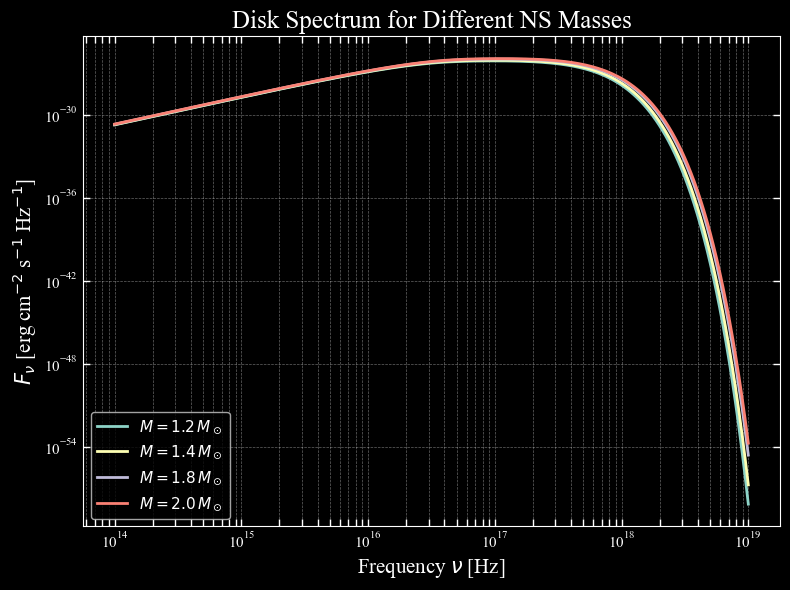

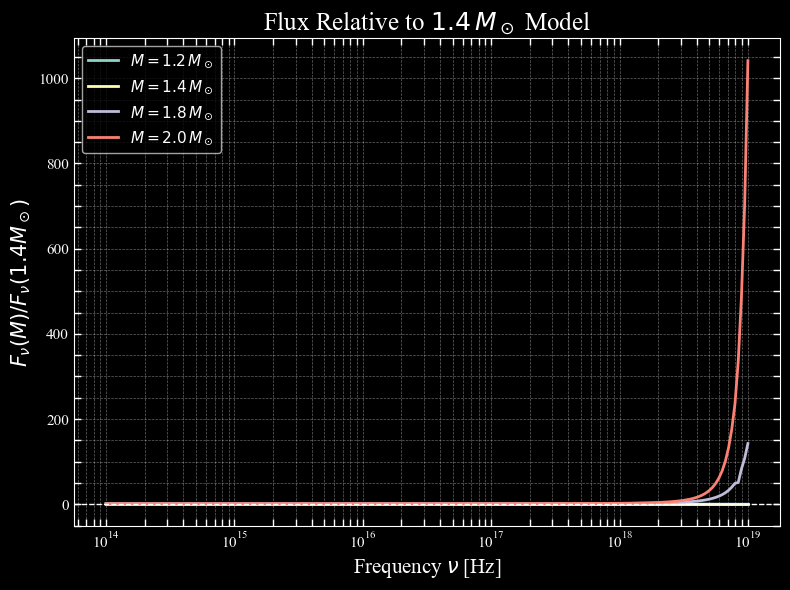

In [44]:
# Varying NS mass (pt. 2)

masses = [1.2, 1.4, 1.8, 2.0]

# dictionary to store each spectrum
spectra = {}

plt.figure(figsize=(8, 6))

for mass in masses:

    M = mass * M_sun

    fluxes = []

    for nu in frequencies:

        F = disk_flux_nu(
            nu * u.Hz,
            M,
            Mdot,
            R_in,
            R_out,
            inclination,
            D
        )

        #convert units
        F_cgs = F.to_value(u.erg / (u.cm**2 * u.s * u.Hz))  

        fluxes.append(F_cgs)

    fluxes_cgs = np.array(fluxes)

   
    # save spectrum so we can use it later
    spectra[mass] = fluxes_cgs

    # plot spectrum
    plt.loglog(
        frequencies,
        fluxes_cgs,
        label=fr"$M = {mass}\,M_\odot$",
        linewidth=2
    )

# labels
plt.xlabel(r"Frequency $\nu$ [Hz]", fontsize=15)

plt.ylabel(
    r"$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]",
    fontsize=15
)

plt.title(
    "Disk Spectrum for Different NS Masses",
    fontsize=18
)

plt.legend(fontsize=11)

plt.minorticks_on()

plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="in",
    length=5,
    width=1
)

ax = plt.gca()

ax.xaxis.set_major_locator(
    ticker.LogLocator(base=10, numticks=6)
)

ax.yaxis.set_major_locator(
    ticker.LogLocator(base=10, numticks=6)
)

ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

plt.show()

# Flux ratio relative to 1.4 solar masses as a reference point.
reference_mass = 1.4

reference_flux = spectra[reference_mass]

plt.figure(figsize=(8, 6))

for mass in masses:

    flux_ratio = spectra[mass] / reference_flux

    plt.semilogx(
        frequencies,
        flux_ratio,
        label=fr"$M = {mass}\,M_\odot$",
        linewidth=2
    )

# Reference line
plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    r"Frequency $\nu$ [Hz]",
    fontsize=15
)

plt.ylabel(
    r"$F_\nu(M) / F_\nu(1.4M_\odot)$",
    fontsize=15
)

plt.title(
    r"Flux Relative to $1.4\,M_\odot$ Model",
    fontsize=18
)

plt.legend(fontsize=11)

plt.minorticks_on()

plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="in",
    length=5,
    width=1
)

ax = plt.gca()

ax.xaxis.set_major_locator(
    ticker.LogLocator(base=10, numticks=6)
)

ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

plt.show()

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/1512803435.py:15: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)
/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_98277/4073746174.py:46: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = quad(


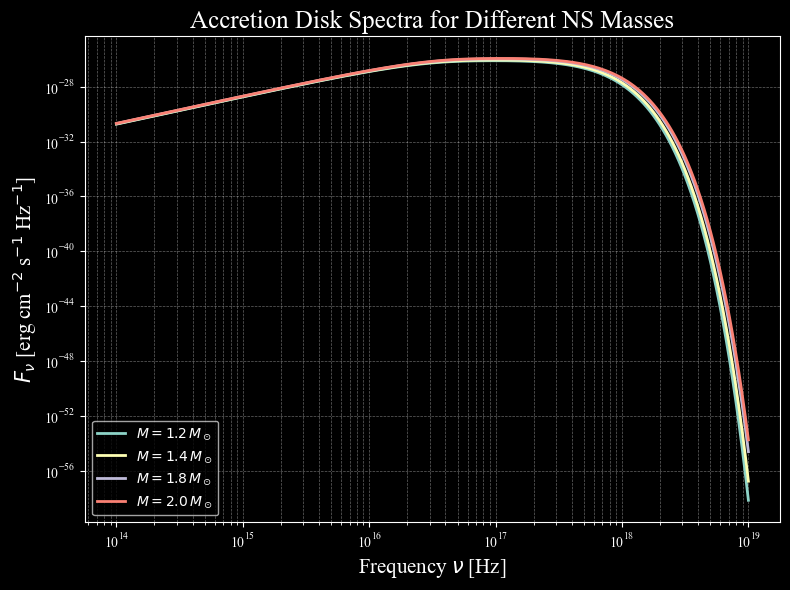

In [45]:
# Making a general case

def compare_ns_masses(
        masses,
        frequencies,
        Mdot,
        R_in,
        R_out,
        inclination,
        D
):

    plt.figure(figsize=(8, 6))

    for mass in masses:
        M = mass * M_sun
        fluxes = []
        for nu in frequencies:
            F = disk_flux_nu(
                nu * u.Hz,
                M,
                Mdot,
                R_in,
                R_out,
                inclination,
                D
            )
            fluxes.append(F)

        # Convert fluxes to cgs units for plotting
        fluxes_cgs = np.array([
            f.to_value(
                u.erg / (u.cm**2 * u.s * u.Hz)
                ) 
                for f in fluxes
        ])

        plt.loglog(
            frequencies,
            fluxes_cgs,
            label=fr"$M = {mass}\,M_\odot$",
            linewidth=2
        )

    plt.xlabel(r"Frequency $\nu$ [Hz]", fontsize=15)
    plt.ylabel(
        r"$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]",
        fontsize=15
    )

    plt.title(
        "Accretion Disk Spectra for Different NS Masses",
        fontsize=18
    )

    plt.grid(
        True,
        which="both",
        ls="--",
        lw=0.5,
        alpha=0.4
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

#ex

masses = [1.2, 1.4, 1.8, 2.0]

frequencies = np.logspace(14, 19, 200)

compare_ns_masses(
    masses,
    frequencies,
    Mdot,
    R_in,
    R_out,
    inclination,
    D
)

In [46]:
# Beginning to add dust extinction to the disk model.

def apply_extinction(F_nu, nu, E_BV, g_lambda):
    """
    Apply interstellar dust extinction to the intrinsic spectrum.

    Parameters:
    -----------
    F_nu : Observed flux without extinction
    nu : Frequency of observation
    E_BV : Color excess (E(B-V))
    g_lambda : Extinction curve function (wavelength-dependence of extinction)

    Returns:
    F_nu_obs : Flux after applying dust extinction
    """

    # Convert frequency to wavelength in microns
    wavelength = (c / nu).to(u.micron) 

    # Calculate the extinction at the given frequency
    A_lambda = g_lambda(wavelength) * E_BV
    
    # Convert A_lambda from magnitudes to a multiplicative factor
    extinction_factor = 10**(-0.4 * A_lambda)
    
    # Apply the extinction to the observed flux
    F_nu_obs = F_nu * extinction_factor
    
    return F_nu_obs

In [47]:
# Testing this

def g_lambda_test(wavelength):
    """
    Simple test extinction curve.
    """

    return 3.1 * (wavelength.value / 0.55)**(-1)

nu = 1e17 * u.Hz

F_nu = disk_flux_nu(
    nu,
    M,
    Mdot,
    R_in,
    R_out,
    inclination,
    D
)

print("Intrinsic flux:", F_nu)

E_BV = 0.2
# E_BV = 0.0   # no extinction
# E_BV = 0.1   # low extinction
# E_BV = 0.5   # stronger extinction
# E_BV = 1.0   # very strong extinction

F_nu_extincted = apply_extinction(
    F_nu,
    nu,
    E_BV,
    g_lambda_test
)

print("Intrinsic flux:", F_nu)
print("Extincted flux:", F_nu_extincted)

wavelength = (c / nu).to(u.micron)

g = g_lambda_test(wavelength)
A_lambda = g * E_BV
extinction_factor = 10**(-0.4 * A_lambda)

print("Frequency:", nu)
print("Wavelength:", wavelength)
print("g(lambda):", g)
print("A(lambda):", A_lambda)
print("Extinction factor:", extinction_factor)
print("Intrinsic flux:", F_nu)
print("Extincted flux:", F_nu_extincted)

Intrinsic flux: 108912697958980.48 Hz3 s3 cm2 J / (kpc2 m2)
Intrinsic flux: 108912697958980.48 Hz3 s3 cm2 J / (kpc2 m2)
Extincted flux: 3.458883474244869e-32 Hz3 s3 cm2 J / (kpc2 m2)
Frequency: 1e+17 Hz
Wavelength: 0.00299792458 micron
g(lambda): 568.7267823128493
A(lambda): 113.74535646256987
Extinction factor: 3.175831229107537e-46
Intrinsic flux: 108912697958980.48 Hz3 s3 cm2 J / (kpc2 m2)
Extincted flux: 3.458883474244869e-32 Hz3 s3 cm2 J / (kpc2 m2)
